In [ ]:
from google.colab import drive
import os

if not os.path.ismount('/content/drive'):
    # Clear any existing content at the mount point (use with caution!)
    !rm -rf /content/drive
    drive.mount('/content/drive')
else:
    print("✅ Google Drive is already mounted!")

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import math

# --- Configuration ---
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"
IMG_SIZE = (224, 224)  # EfficientNetB0 default
BATCH_SIZE = 16
EPOCHS_TOTAL = 30
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]

# --- Data Augmentation ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Testing"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Class Weights ---
y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# --- Load Base Model ---
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# --- Build Model ---
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(len(CLASS_NAMES), activation='softmax')
])

# --- Compile Phase 1 ---
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# --- Callbacks ---
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=2, verbose=1)

# --- Phase 1: Train Top Layers ---
print("\n🔧 Training top layers...\n")
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# --- Phase 2: Fine-tune Full Model ---
print("\n🧠 Fine-tuning entire model...\n")
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Cosine annealing schedule
def cosine_annealing(epoch):
    max_lr = 1e-3
    min_lr = 1e-5
    return min_lr + (max_lr - min_lr) * (1 + math.cos(math.pi * epoch / EPOCHS_TOTAL)) / 2

lr_scheduler = LearningRateScheduler(cosine_annealing)

model.compile(
    optimizer=SGD(learning_rate=1e-4, momentum=0.9, nesterov=True),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# --- Train ---
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=1
)

# --- Save Final Model ---
model.save("efficientnetB0_brain_tumor.keras")
print("\n💾 Model saved as efficientnetB0_brain_tumor.keras")


Found 3696 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🔧 Training top layers...



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 1287s 5s/step - accuracy: 0.4311 - loss: 2.6293 - val_accuracy: 0.7134 - val_loss: 1.9467 - learning_rate: 1.0000e-04
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 72s 314ms/step - accuracy: 0.6335 - loss: 2.1550 - val_accuracy: 0.7487 - val_loss: 1.8757 - learning_rate: 1.0000e-04
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 74s 319ms/step - accuracy: 0.6871 - loss: 2.0265 - val_accuracy: 0.7879 - val_loss: 1.7998 - learning_rate: 1.0000e-04
Epoch 4/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 74s 321ms/step - accuracy: 0.7239 - loss: 1.9456 - val_accuracy: 0.8081 - val_loss: 1.7401 - learning_rate: 1.0000e-04
Epoch 5/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 73s 316ms/step - accuracy: 0.7329 - loss: 1.8924 - val_accuracy: 0.8030 - val_loss: 1.7423 - learning_rate: 1.0000e-04
Epoch 6/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 74s 318ms/step - accuracy: 0.7548 - loss: 1.8521 - val_accuracy: 0.8131 - val_loss: 1.6961 - learning_rate: 1.0000e-04
Epoch 7/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 73s 316

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 270s 5s/step


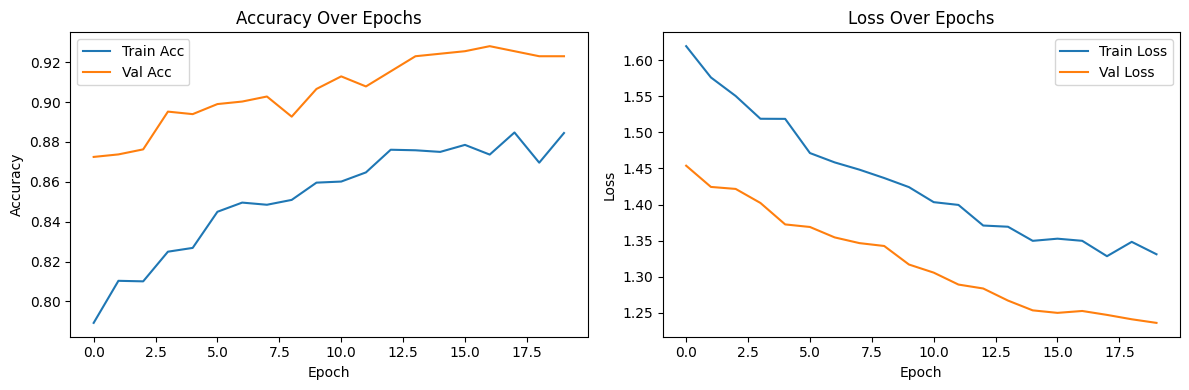

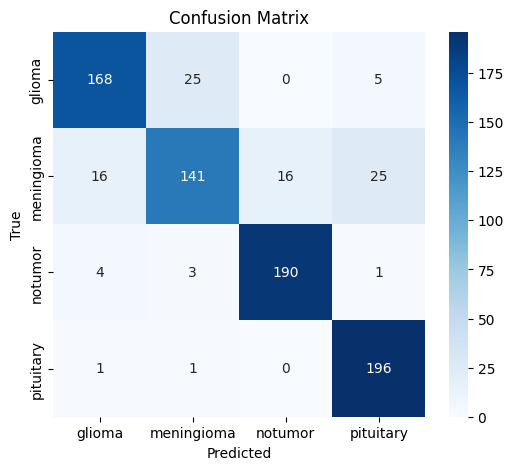

NameError: name 'pd' is not defined

<Figure size 800x400 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import os
import tensorflow as tf
import pandas as pd

# --- Load Model ---
model = tf.keras.models.load_model("efficientnetB0_brain_tumor.keras")

# --- Predict ---
test_generator.reset()
y_probs = model.predict(test_generator)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# --- 1. Accuracy & Loss Curves ---
def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# If `history` is in memory
# plot_history(history) # This line should be uncommented if `history` object is available in the environment.

# --- 2. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# --- 3. Classification Report ---
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
plt.figure(figsize=(8, 4))
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report")
plt.show()

# --- 4. ROC Curve (One-vs-Rest) ---
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - One-vs-Rest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# --- 5. Prediction Samples: Correct & Incorrect ---
idx_to_class = {v: k for k, v in test_generator.class_indices.items()}
file_paths = test_generator.filepaths
examples = {cls: {'positive': None, 'negative': None} for cls in class_labels}

for i in range(len(y_true)):
    true_label = idx_to_class[y_true[i]]
    pred_label = idx_to_class[y_pred[i]]
    path = file_paths[i]

    if examples[true_label]['positive'] is None and true_label == pred_label:
        examples[true_label]['positive'] = (path, true_label, pred_label)
    if examples[true_label]['negative'] is None and true_label != pred_label:
        examples[true_label]['negative'] = (path, true_label, pred_label)
    if all(v['positive'] and v['negative'] for v in examples.values()):
        break

plt.figure(figsize=(12, 10))
plot_index = 1

for cls in class_labels:
    for case_type, label in zip(['positive', 'negative'], ['✅ Correct', '❌ Incorrect']):
        file_path, true_lbl, pred_lbl = examples[cls][case_type]
        image = plt.imread(file_path)

        plt.subplot(len(class_labels), 2, plot_index)
        plt.imshow(image)
        plt.title(f"{label}\nTrue: {true_lbl}\nPred: {pred_lbl}",
                  color='green' if label == '✅ Correct' else 'red')
        plt.axis('off')
        plot_index += 1

plt.suptitle("Prediction Examples per Class (Correct & Incorrect)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

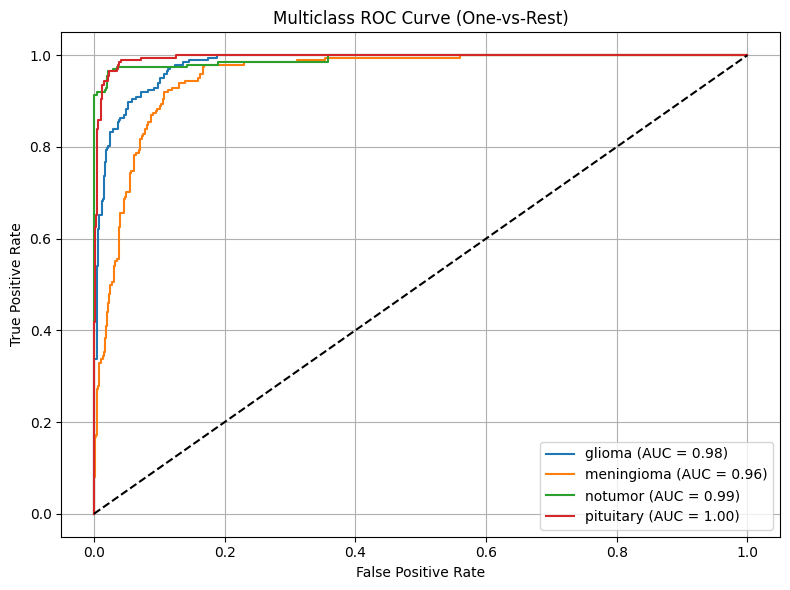

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Ensure consistent class order
class_indices = test_generator.class_indices
class_labels = list(class_indices.keys())
n_classes = len(class_labels)

# Binarize y_true
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# Plot ROC curve for each class
fpr, tpr, roc_auc = {}, {}, {}
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-5-3292300671>:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
<ipython-input-5-3292300671>:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


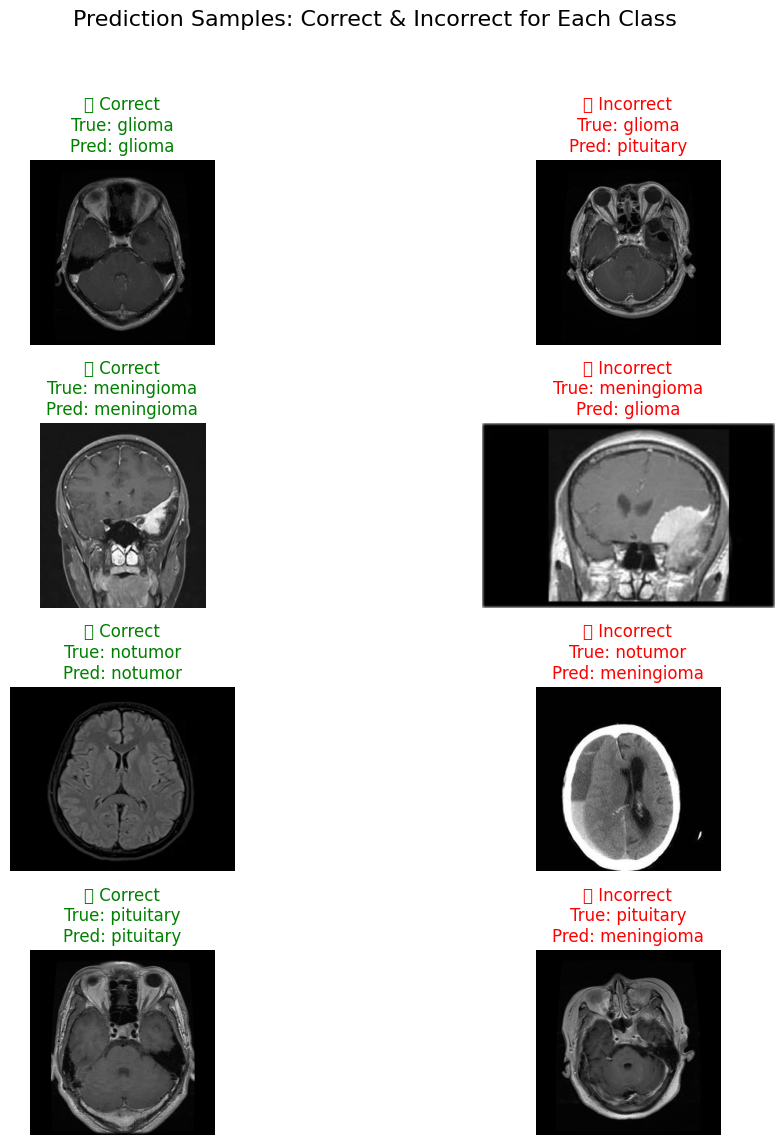

In [ ]:
import matplotlib.pyplot as plt
import os

# Reverse mapping
idx_to_class = {v: k for k, v in test_generator.class_indices.items()}
file_paths = test_generator.filepaths

# Initialize structure to hold examples
examples = {cls: {'positive': None, 'negative': None} for cls in class_labels}

# Loop through predictions
for i, (true, pred) in enumerate(zip(y_true, y_pred)):
    true_class = idx_to_class[true]
    pred_class = idx_to_class[pred]
    path = file_paths[i]

    if true == pred and examples[true_class]['positive'] is None:
        examples[true_class]['positive'] = (path, true_class, pred_class)
    if true != pred and examples[true_class]['negative'] is None:
        examples[true_class]['negative'] = (path, true_class, pred_class)

    # Stop early when all slots filled
    if all(examples[c]['positive'] and examples[c]['negative'] for c in class_labels):
        break

# Plot examples
plt.figure(figsize=(12, len(class_labels) * 3))
plot_index = 1

for cls in class_labels:
    for case, label in zip(['positive', 'negative'], ['✅ Correct', '❌ Incorrect']):
        if examples[cls][case]:
            path, true_lbl, pred_lbl = examples[cls][case]
            img = plt.imread(path)

            plt.subplot(len(class_labels), 2, plot_index)
            plt.imshow(img)
            plt.title(f"{label}\nTrue: {true_lbl}\nPred: {pred_lbl}",
                      color='green' if label == '✅ Correct' else 'red')
            plt.axis('off')
            plot_index += 1

plt.suptitle("Prediction Samples: Correct & Incorrect for Each Class", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import math

# --- Configuration ---
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"
IMG_SIZE = (224, 224)  # EfficientNetB0 default
BATCH_SIZE = 16
EPOCHS_TOTAL = 30
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]

# --- Data Augmentation ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Testing"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Class Weights ---
y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# --- Load Base Model ---
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# --- Build Model ---
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(len(CLASS_NAMES), activation='softmax')
])
model.summary()

Found 3696 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,842,919 (18.47 MB)

 Trainable params: 790,788 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
import os

root = "/content/drive/MyDrive/BalancedBrainTumorDataset"

print("Training classes:", os.listdir(os.path.join(root, "Training")))
print("Validation classes:", os.listdir(os.path.join(root, "Validation")))
print("Testing classes:", os.listdir(os.path.join(root, "Testing")))


Training classes: ['glioma', 'meningioma', 'pituitary', 'notumor']
Validation classes: ['glioma', 'meningioma', 'pituitary', 'notumor']
Testing classes: ['glioma', 'meningioma', 'pituitary', 'notumor']


In [ ]:
# -----------------------------------------------------------
#   EfficientNetB0 - 5-Fold Cross Validation (RAM-SAFE)
#   Phase 1 = 10 epochs, Phase 2 = 20 epochs
#   Uses: BalancedBrainTumorDataset/Training
# -----------------------------------------------------------

import os
import math
import gc
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------------------------------------
# CONFIG
# -----------------------------------------------------------
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset/Training"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16                      # safe & not too heavy
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]
NUM_CLASSES = len(CLASS_NAMES)

EPOCHS_PHASE1 = 10                   # your original setting
EPOCHS_PHASE2 = 20                   # your original setting
FOLDS = 5

# -----------------------------------------------------------
# LOAD ALL IMAGE PATHS + LABELS
# -----------------------------------------------------------
def load_paths_labels():
    filepaths = []
    labels = []
    for label, cls in enumerate(CLASS_NAMES):
        cls_folder = os.path.join(DATASET_PATH, cls)
        for fname in os.listdir(cls_folder):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                filepaths.append(os.path.join(cls_folder, fname))
                labels.append(label)
    return np.array(filepaths), np.array(labels)

X_paths, y_labels = load_paths_labels()
print("Total Training Images:", len(X_paths))

# -----------------------------------------------------------
# DATA GENERATORS
# -----------------------------------------------------------
train_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
)

val_aug = ImageDataGenerator(preprocessing_function=preprocess_input)

def build_flow(paths, labels, augment):
    """Builds a DataFrame iterator with correct class names and no shuffle for val."""
    df = pd.DataFrame({
        "filename": paths,
        "class": np.array(CLASS_NAMES)[labels]
    })

    datagen = train_aug if augment else val_aug

    gen = datagen.flow_from_dataframe(
        dataframe=df,
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE,
        class_mode="categorical",
        batch_size=BATCH_SIZE,
        shuffle=augment  # True for train, False for val
    )
    return gen

# -----------------------------------------------------------
# MODEL BUILDER
# -----------------------------------------------------------
def build_model():
    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    model = Sequential([
        base,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.4),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

# -----------------------------------------------------------
# COSINE ANNEALING LR
# -----------------------------------------------------------
def cosine_annealing(epoch):
    max_lr = 1e-3
    min_lr = 1e-5
    total_epochs = EPOCHS_PHASE1 + EPOCHS_PHASE2
    return min_lr + (max_lr - min_lr) * (1 + math.cos(math.pi * epoch / total_epochs)) / 2

# -----------------------------------------------------------
# 5-FOLD CROSS VALIDATION (RAM-SAFE)
# -----------------------------------------------------------
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_paths, y_labels), 1):
    print(f"\n========== FOLD {fold} / {FOLDS} ==========")

    # Split paths & labels
    train_x, val_x = X_paths[train_idx], X_paths[val_idx]
    train_y, val_y = y_labels[train_idx], y_labels[val_idx]

    # Compute class weights per fold (balanced)
    class_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    class_weights_dict = dict(enumerate(class_weights))

    # Build generators
    train_gen = build_flow(train_x, train_y, augment=True)
    val_gen   = build_flow(val_x, val_y, augment=False)

    # Build model
    model = build_model()

    # ---------------- PHASE 1 (10 epochs, frozen base) ----------------
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
    reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=2, verbose=1)

    print("\n🔧 Phase 1 Training...\n")
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_PHASE1,
        class_weight=class_weights_dict,
        callbacks=[early, reduce],
        verbose=1
    )

    # ---------------- PHASE 2 (20 epochs, fine-tuning) ----------------
    model.layers[0].trainable = True  # unfreeze EfficientNetB0 base

    model.compile(
        optimizer=SGD(learning_rate=1e-4, momentum=0.9, nesterov=True),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy']
    )

    lr_sched = LearningRateScheduler(cosine_annealing)

    print("\n🧠 Fine-Tuning Phase 2...\n")
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_PHASE2,
        class_weight=class_weights_dict,
        callbacks=[early, reduce, lr_sched],
        verbose=1
    )

    # ---------------- RAM-SAFE PREDICTION ----------------
    # predict in small batches to avoid RAM spike
    print("\n📊 Generating predictions for validation set (RAM-safe)...\n")
    preds_list = []
    for i in range(len(val_gen)):
        batch_x, _ = val_gen[i]
        batch_pred = model.predict(batch_x, verbose=0)
        preds_list.append(batch_pred)
    preds = np.vstack(preds_list)

    y_pred = np.argmax(preds, axis=1)
    y_true = val_y  # labels correspond to X_paths → same order as val_gen with shuffle=False

    # ---------------- METRICS ----------------
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    auc = roc_auc_score(to_categorical(y_true, num_classes=NUM_CLASSES), preds, multi_class='ovr')

    results.append([acc, prec, rec, f1, auc])

    print(f"\nFOLD {fold} RESULTS:")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"AUC       : {auc:.4f}")

    # ---------------- CLEAR RAM AFTER EACH FOLD ----------------
    del model, train_gen, val_gen, preds, preds_list, y_pred
    tf.keras.backend.clear_session()
    gc.collect()

# -----------------------------------------------------------
# FINAL SUMMARY
# -----------------------------------------------------------
results = np.array(results)
mean, std = results.mean(axis=0), results.std(axis=0)

print("\n========== FINAL 5-FOLD CV SUMMARY (EfficientNetB0) ==========\n")
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]
for i, m in enumerate(metrics):
    print(f"{m}: {mean[i]:.4f} ± {std[i]:.4f}")
